# Chicken disease prediction

### Deep Neural Networks: Building, Tuning, and Optimizing Neural Networks

The annotated dataset of poultry disease diagnostics for small to medium-scale poultry farmers consists of poultry fecal images. The poultry fecal images were taken in Arusha and Kilimanjaro regions in Tanzania between September 2020 and February 2021 using Open Data Kit (ODK) app on mobile phones. The classes are "Coccidiosis" ,"Healthy", "New Castle Disease" ,"Salmonella". The images are resized to 224px by 224px.

Objectives:
1. Building deep neural networks using Keras
2. Tuning with normalization techniques
3. Tuning with regularization techniques
4. Optimization strategies for better performance4.
5. Compare LIME vs SHAP approaches
6. Apply interpretability to neural networks
7. Visualize and communicate model decisions


## Setup and Dependencies

In [1]:
#!pip install lime
#!pip install shap

In [2]:
# core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

#machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import array_to_img, img_to_array, load_img


#Interpretabilty libraries
import lime
import lime.lime_tabular
import lime.lime_image
import shap

#Utilities
import warnings
warnings.filterwarnings('ignore')

#Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

c:\Users\Latifa Riziki\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Latifa Riziki\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
# Load the training labels
train_df = pd.read_csv('data/train_data.csv')
print(f"Total training images: {len(train_df)}")
print(train_df.head())

# Create an ImageDataGenerator with validation split
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

img_dir = 'data/Train'

print("\nLoading Training Data...")
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=img_dir,
    x_col='images',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

print("\nLoading Validation Data...")
val_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=img_dir,
    x_col='images',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Total training images: 8067
           images               label
0  salmo.1558.jpg          Salmonella
1  cocci.1866.jpg         Coccidiosis
2   cocci.171.jpg         Coccidiosis
3  salmo.1484.jpg          Salmonella
4     ncd.100.jpg  New Castle Disease

Loading Training Data...
Found 6454 validated image filenames belonging to 4 classes.

Loading Validation Data...
Found 1613 validated image filenames belonging to 4 classes.


In [4]:
# create the datasets
train_images, train_labels = next(train_generator)
val_images, val_labels = next(val_generator)


In [10]:
# Check the shape of your arrays
print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Validation images shape: {val_images.shape}")
print(f"Validation labels shape: {val_labels.shape}")

Train images shape: (32, 224, 224, 3)
Train labels shape: (32, 4)
Validation images shape: (32, 224, 224, 3)
Validation labels shape: (32, 4)


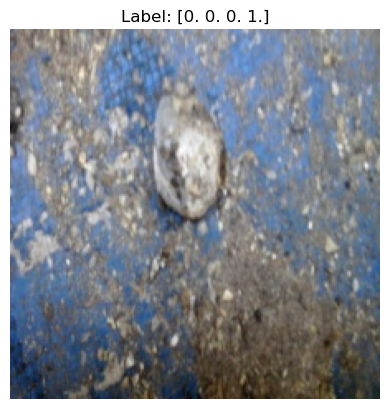

In [11]:
# Look at the first image in training set
img = array_to_img(train_images[0])
plt.imshow(img)
plt.title(f"Label: {train_labels[0]}")
plt.axis('off')
plt.show()

### The shape of the data

In [13]:
# Look at the shape of each array
print("train_images shape:", np.shape(train_images))
print("train_labels shape:", np.shape(train_labels))
print("Val_images shape:", np.shape(val_images))
print("Val_labels shape:", np.shape(val_labels))

train_images shape: (32, 224, 224, 3)
train_labels shape: (32, 4)
Val_images shape: (32, 224, 224, 3)
Val_labels shape: (32, 4)


### `train_images` and `validation_images`

In [15]:
train_images_reshaped = train_images.reshape(32, -1).T

# Check the new shape
print("Original shape:", np.shape(train_images))
print("Reshaped shape:", np.shape(train_images_reshaped))

# Verify the dimensions
expected_features = 224 * 224 * 3
print(f"Expected features: {expected_features}")
print(f"Actual features: {train_images_reshaped.shape[0]}")
print(f"Number of images: {train_images_reshaped.shape[1]}")

Original shape: (32, 224, 224, 3)
Reshaped shape: (150528, 32)
Expected features: 150528
Actual features: 150528
Number of images: 32


In [16]:
val_images_reshaped = val_images.reshape(32, -1).T

# Check the new shape
print("Original shape:", np.shape(val_images))
print("Reshaped shape:", np.shape(train_images_reshaped))

# Verify the dimensions
expected_features = 224 * 224 * 3
print(f"Expected features: {expected_features}")
print(f"Actual features: {val_images_reshaped.shape[0]}")
print(f"Number of images: {val_images_reshaped.shape[1]}")


Original shape: (32, 224, 224, 3)
Reshaped shape: (150528, 32)
Expected features: 150528
Actual features: 150528
Number of images: 32


### `train_labels` and `val_labels`

In [18]:
train_labels

array([[0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]], dtype=float32)

In [19]:
train_generator.class_indices

{'Coccidiosis': 0, 'Healthy': 1, 'New Castle Disease': 2, 'Salmonella': 3}

from the output `Coccidiosis`: 0, `Healthy`: 1, `New Castle Disease`: 2, `Salmonella`: 3

In [20]:
# Keep all classes - shape (32, 4)
print("Full labels shape:", train_labels.shape)
print("First image label:", train_labels[0])  # Shows which disease

# When training, the model will output 4 probabilities
# The highest probability determines the prediction

Full labels shape: (32, 4)
First image label: [0. 0. 0. 1.]


### Standardize the data

In [21]:
# Divide by 255 to scale pixel values between 0 and 1
train_images_normalized = train_images_reshaped / 255.0
val_images_normalized = val_images_reshaped / 255.0

# Check the results
print("Original train_images min:", train_images_reshaped.min())
print("Original train_images max:", train_images_reshaped.max())
print("Normalized train_images min:", train_images_normalized.min())
print("Normalized train_images max:", train_images_normalized.max())

Original train_images min: 0.0
Original train_images max: 1.0
Normalized train_images min: 0.0
Normalized train_images max: 0.003921569


In [5]:
train_df.shape

(8067, 2)

### Build a logistic regression-based neural network

In [6]:
#checking for class balance
train_df['label'].value_counts()

label
Salmonella            2625
Coccidiosis           2476
Healthy               2404
New Castle Disease     562
Name: count, dtype: int64

In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8067 entries, 0 to 8066
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   images  8067 non-null   str  
 1   label   8067 non-null   str  
dtypes: str(2)
memory usage: 316.9 KB


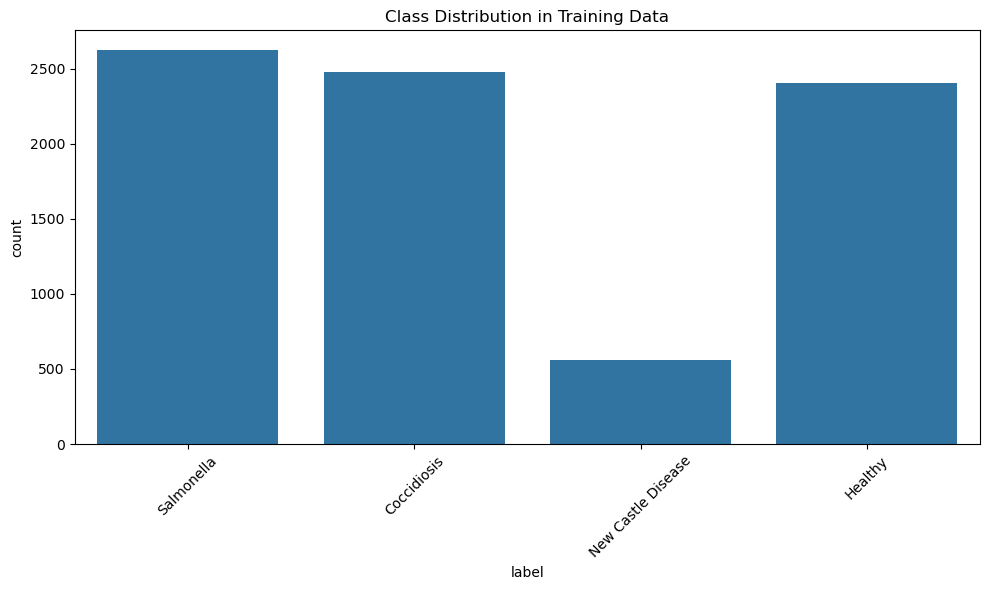

In [8]:
# visualize class distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='label')
plt.title('Class Distribution in Training Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
import cv2
from PIL import Image

# Set image directory
img_dir = 'data/Train'

# Check a few sample images
def sample_image_analysis(train_df, img_dir, n_samples=5):
    # Randomly select some images
    samples = train_df.sample(n=n_samples)
    
    fig, axes = plt.subplots(1, n_samples, figsize=(15, 3))
    
    for idx, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(img_dir, row['images'])
        
        # Load image
        img = Image.open(img_path)
        
        # Display image
        axes[idx].imshow(img)
        axes[idx].set_title(f"Label: {row['label']}")
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

sample_image_analysis(train_df, img_dir)

# Analyze image properties
def analyze_image_properties(train_df, img_dir, n_samples=100):
    # Take a sample of images for analysis
    samples = train_df.sample(n=min(n_samples, len(train_df)))
    
    image_sizes = []
    image_modes = []
    image_channels = []
    
    for _, row in samples.iterrows():
        img_path = os.path.join(img_dir, row['images'])
        img = Image.open(img_path)
        
        # Get image properties
        image_sizes.append(img.size)  # (width, height)
        image_modes.append(img.mode)
        
        # For color channels
        if len(np.array(img).shape) == 3:
            image_channels.append(np.array(img).shape[2])
        else:
            image_channels.append(1)  # Grayscale
    
    # Convert to DataFrame for analysis
    sizes_df = pd.DataFrame(image_sizes, columns=['width', 'height'])
    
    print("Image Size Statistics:")
    print(sizes_df.describe())
    
    print("\nImage Modes:", set(image_modes))
    print("Color Channels:", set(image_channels))
    
    # Visualize size distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.hist(sizes_df['width'], bins=20, alpha=0.7, label='Width')
    ax1.hist(sizes_df['height'], bins=20, alpha=0.7, label='Height')
    ax1.set_xlabel('Pixels')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Image Dimensions Distribution')
    ax1.legend()
    
    ax2.scatter(sizes_df['width'], sizes_df['height'], alpha=0.6)
    ax2.set_xlabel('Width')
    ax2.set_ylabel('Height')
    ax2.set_title('Width vs Height')
    
    plt.tight_layout()
    plt.show()

analyze_image_properties(train_df, img_dir)

# Check for corrupted images
def check_corrupted_images(train_df, img_dir):
    corrupted = []
    
    for _, row in train_df.iterrows():
        img_path = os.path.join(img_dir, row['images'])
        try:
            img = Image.open(img_path)
            img.verify()  # Verify it's a valid image
        except Exception as e:
            corrupted.append(row['images'])
    
    print(f"Found {len(corrupted)} corrupted images:")
    print(corrupted)
    
    return corrupted

corrupted_images = check_corrupted_images(train_df, img_dir)

# Analyze per class image properties
def per_class_analysis(train_df, img_dir):
    # Get unique classes
    classes = train_df['label'].unique()
    
    for class_name in classes:
        class_images = train_df[train_df['label'] == class_name]
        print(f"\nClass: {class_name}")
        print(f"Number of images: {len(class_images)}")
        
        # Show a few examples
        samples = class_images.sample(n=min(3, len(class_images)))
        fig, axes = plt.subplots(1, len(samples), figsize=(12, 4))
        
        if len(samples) == 1:
            axes = [axes]
        
        for idx, (_, row) in enumerate(samples.iterrows()):
            img_path = os.path.join(img_dir, row['images'])
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(f"{class_name}")
            axes[idx].axis('off')
        
        plt.suptitle(f"Sample images from {class_name}")
        plt.show()

per_class_analysis(train_df, img_dir)

ModuleNotFoundError: No module named 'cv2'